Plot the exported highres pickle files of NenuFAR

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import glob
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import astropy.units as u
from astropy.time import Time
from datetime import datetime, timedelta
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from matplotlib.ticker import AutoMinorLocator
import matplotlib as mpl
mpl.rcParams['date.epoch'] = '1970-01-01T00:00:00' # use precise epoch
try: mdates.set_epoch('1970-01-01T00:00:00')
except: pass


data_dir    = '/home/mnedal/data/ORFEES'
folder_path = '/home/mnedal/data/pkl_files'
outputs     = '/home/mnedal/data/png'

In [2]:
mydate = '20250326'

nenufar_files = sorted(glob.glob(f'{folder_path}/nenufar/*'))
for f in enumerate(nenufar_files):
    print(f)

(0, '/home/mnedal/data/pkl_files/nenufar/combined_dyspec_20250325_093459_20250325_094159_stokesI_typeIII_G1.pkl')
(1, '/home/mnedal/data/pkl_files/nenufar/combined_dyspec_20250325_093459_20250325_094159_stokesV_over_I_typeIII_G1.pkl')
(2, '/home/mnedal/data/pkl_files/nenufar/combined_dyspec_20250325_093459_20250325_094159_stokesV_over_I_typeIII_G1_fullres.pkl')
(3, '/home/mnedal/data/pkl_files/nenufar/combined_dyspec_20250325_094259_20250325_094900_stokesI_typeIII_G2.pkl')
(4, '/home/mnedal/data/pkl_files/nenufar/combined_dyspec_20250325_094259_20250325_094900_stokesV_over_I_typeIII_G2.pkl')
(5, '/home/mnedal/data/pkl_files/nenufar/combined_dyspec_20250325_103529_20250325_104000_stokesI_typeIII_G3.pkl')
(6, '/home/mnedal/data/pkl_files/nenufar/combined_dyspec_20250325_103529_20250325_104000_stokesV_over_I_typeIII_G3.pkl')
(7, '/home/mnedal/data/pkl_files/nenufar/combined_dyspec_20250325_104500_20250325_104900_stokesI_typeIII_G4.pkl')
(8, '/home/mnedal/data/pkl_files/nenufar/combined_dy

In [3]:
SRB_groupname = 'typeII' # typeIII_G1, typeIII_G2, typeIII_G3, typeIII_G4, typeII

g_files = [f for f in nenufar_files if mydate in f and f.endswith(f'{SRB_groupname}.pkl')] # find the filenames that end with G1
print(*g_files, sep='\n')

stokesI_filename  = [f for f in g_files if 'stokesI' in f][0]
stokesVI_filename = [f for f in g_files if 'stokesV_over_I' in f][0]

df_int = pd.read_pickle(stokesI_filename)
df_pol = pd.read_pickle(stokesVI_filename)

# Convert arb. unit to dB for Stokes I
df_int = 10 * np.log10(df_int) # Convert the amplitude to decibels

/home/mnedal/data/pkl_files/nenufar/combined_dyspec_20250326_091312_20250326_095609_stokesI_typeII.pkl
/home/mnedal/data/pkl_files/nenufar/combined_dyspec_20250326_091312_20250326_095609_stokesV_over_I_typeII.pkl


<b>Original cadence:</b>
* Frequency resolution: 6.10 kHz
* Time resolution: 20.97 ms

In [4]:
dyspec_subtracted = df_int - np.tile(np.nanmedian(df_int,0), (df_int.shape[0],1))

print('Stokes I:')
print(f'Frequency resolution: {np.nanmedian(np.diff(df_int.columns)*1e3):.2f} kHz')
print(f'Time resolution: {np.nanmedian(np.diff(df_int.index)/np.timedelta64(1,"ms")):.2f} ms')
print(f'Data shape: {df_int.shape}\n')

print('Stokes V/I:')
print(f'Frequency resolution: {np.nanmedian(np.diff(df_pol.columns)*1e3):.2f} kHz')
print(f'Time resolution: {np.nanmedian(np.diff(df_pol.index)/np.timedelta64(1,"ms")):.2f} ms')
print(f'Data shape: {df_pol.shape}')

Stokes I:
Frequency resolution: 97.66 kHz
Time resolution: 20.97 ms
Data shape: (122882, 640)

Stokes V/I:
Frequency resolution: 97.66 kHz
Time resolution: 20.97 ms
Data shape: (122882, 640)


## Plot the highres dynamic spectra

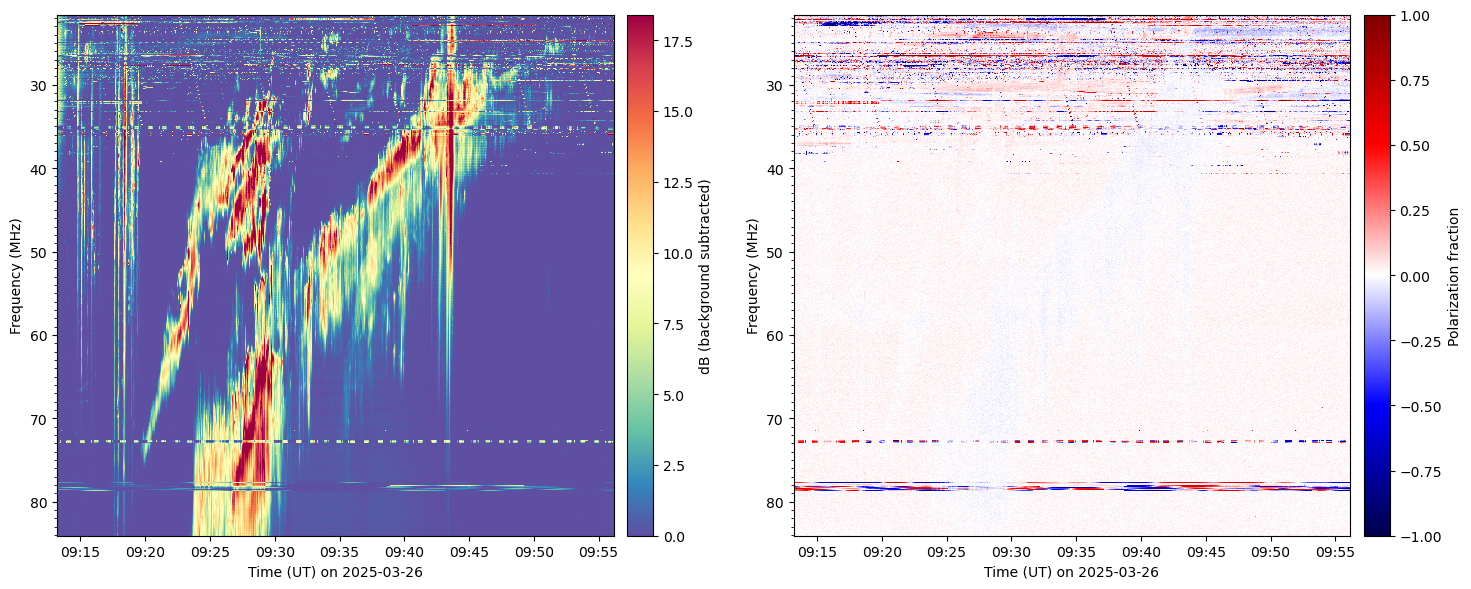

In [5]:
fig = plt.figure(figsize=[15,6])

ax = fig.add_subplot(121)
pc = ax.pcolormesh(dyspec_subtracted.index, dyspec_subtracted.columns, dyspec_subtracted.T,
                   vmin=0, vmax=np.percentile(dyspec_subtracted, 99),
                   cmap='Spectral_r')
fig.colorbar(pc, ax=ax, pad=0.02, label='dB (background subtracted)')
ax.set_xlabel(f'Time (UT) on {df_int.index[0].date()}')
ax.set_ylabel('Frequency (MHz)')
ax.set_ylim(ax.get_ylim()[::-1])
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax.set_xlim(left=pd.Timestamp(f'{df_int.index[0].date()} 09:36:00'),
#             right=pd.Timestamp(f'{df_int.index[0].date()} 09:41:00'))

ax = fig.add_subplot(122)
pc = ax.pcolormesh(df_pol.index, df_pol.columns, df_pol.T,
                   vmin=-1, vmax=1,
                   cmap='seismic')
fig.colorbar(pc, ax=ax, pad=0.02, label='Polarization fraction')
ax.set_xlabel(f'Time (UT) on {df_pol.index[0].date()}')
ax.set_ylabel('Frequency (MHz)')
ax.set_ylim(ax.get_ylim()[::-1])
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax.set_xlim(left=pd.Timestamp(f'{df_pol.index[0].date()} 09:36:00'),
#             right=pd.Timestamp(f'{df_pol.index[0].date()} 09:41:00'))
fig.tight_layout()
plt.show()

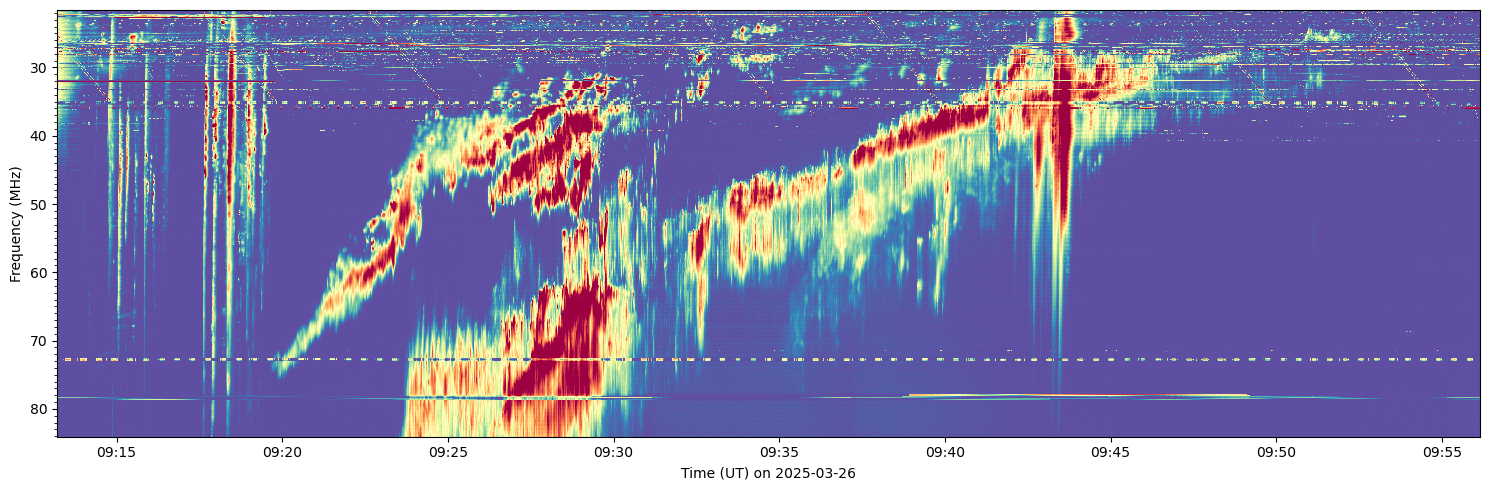

In [6]:
fig = plt.figure(figsize=[15,5])
ax = fig.add_subplot()
ax.pcolormesh(dyspec_subtracted.index, dyspec_subtracted.columns, dyspec_subtracted.T,
              vmin=0, vmax=np.nanpercentile(dyspec_subtracted, 98), cmap='Spectral_r')
ax.set_xlabel(f'Time (UT) on {df_int.index[0].date()}')
ax.set_ylabel('Frequency (MHz)')
ax.set_ylim(ax.get_ylim()[::-1])
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax.set_xlim(left=pd.Timestamp(f'{df_int.index[0].date()} 09:36:00'),
#             right=pd.Timestamp(f'{df_int.index[0].date()} 09:41:00'))
fig.tight_layout()
plt.show()

---

# Shock analysis of the type II radio burst, 26 March 2025 (NenuFAR)

Everything above loads and displays the dynamic spectra. Everything below turns the type II burst
in them into a set of shock characteristics.

The analysis code is in the `typeii` package next to this notebook; the method, the formulas and
the conventions are in **`METHODS.md`**, and the figure and table captions are in
**`FIGURES_AND_TABLES.md`**. Each heading below names the section of `METHODS.md` that describes
what the cell under it does. Every constant and tunable is in `typeii/config.py`.

Run the cells in order. Only one needs you: the tracer in &sect;A.3, where the lanes are placed by
hand.

## Setup

In [7]:
import typeii as t2
from typeii import config as cfg, pipeline as pl
from typeii.session import Run

run = Run(df_int, df_pol, dyspec_subtracted, outputs)
run

<Run 2025-03-26: 9 attributes, OUTDIR=/home/mnedal/data/png/type2_nenufar>

## A.1 &middot; The tracing layer

*Method: `METHODS.md` &sect;3*

decimating:   0%|          | 0/5 [00:00<?, ?it/s]

decimating:   0%|          | 0/5 [00:00<?, ?it/s]

Stokes I layer: 3891 time x 605 freq (decimated 25x in time, 1x in frequency)
  09:18:00.253557-09:51:59.733875 UT, 25.0-84.0 MHz, cadence 524 ms, channel 98 kHz
Stokes V/I layer: 3891 time x 605 freq (decimated 25x in time, 1x in frequency)

BEZIER_JITTER = 6.1 channels, derived from BEZIER_JITTER_MHZ = 0.4 MHz
  (98 kHz per channel, divided by the 0.676 cubic attenuation). The traced-lanes figure reports the spread actually achieved.
saved /home/mnedal/data/png/type2_nenufar/display_stretch_comparison.png


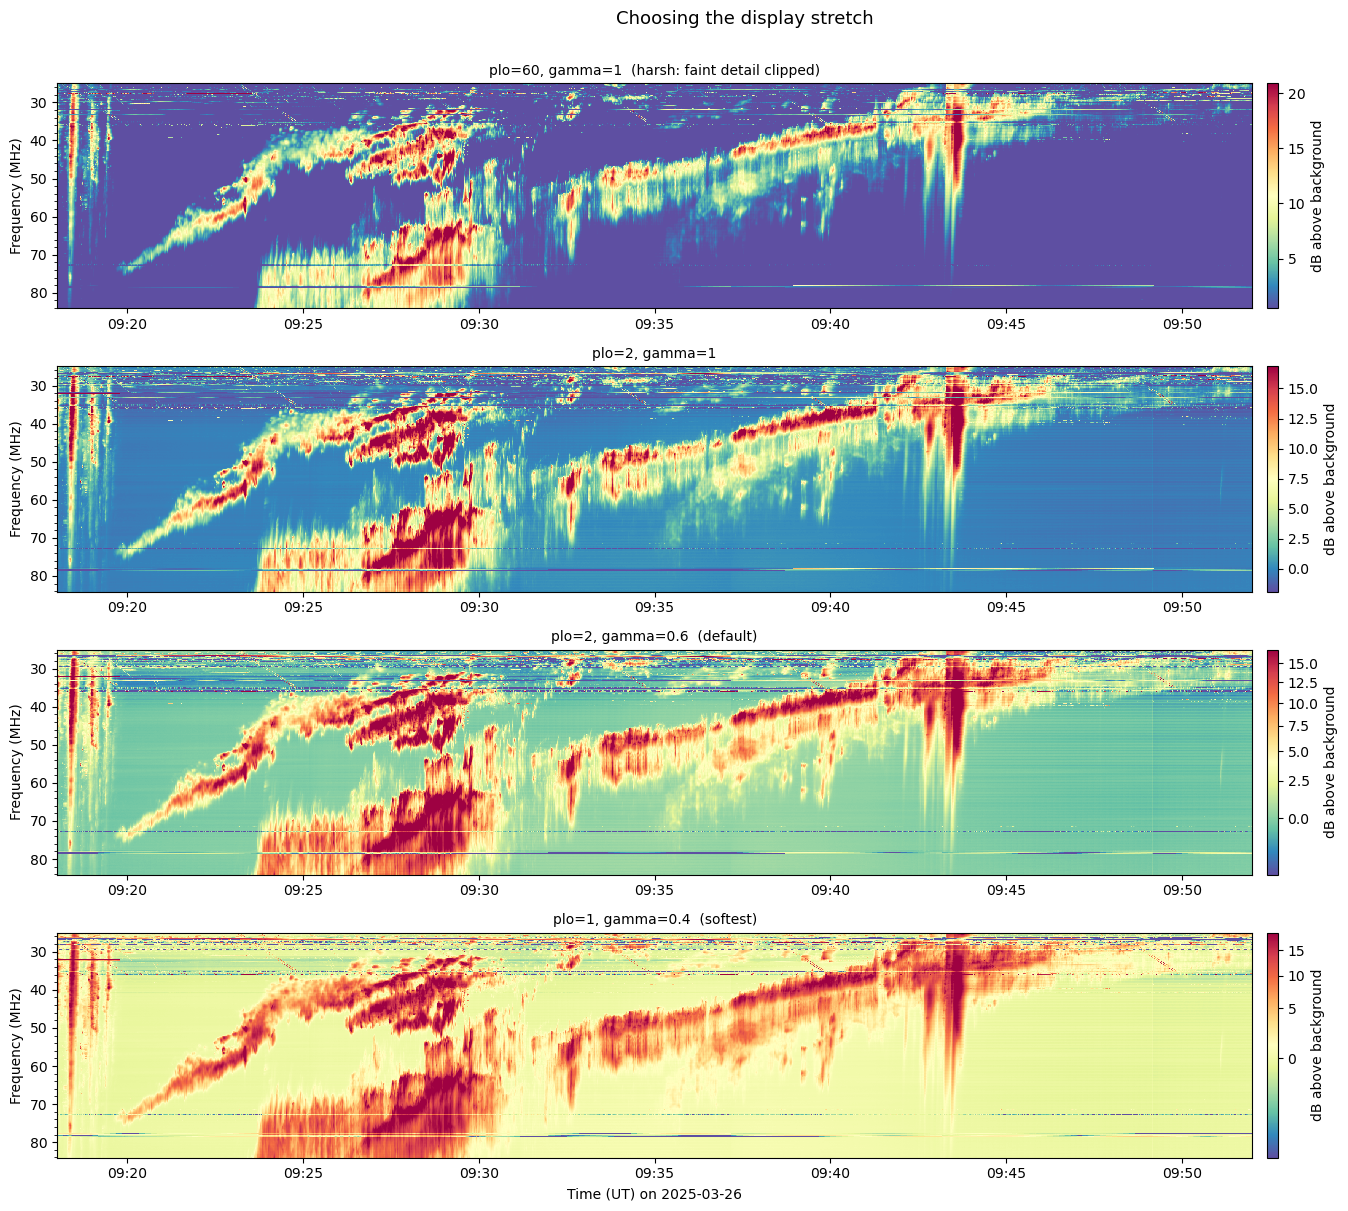

In [8]:
pl.build_layer(run)
pl.plot_stretch_comparison(run)

## A.1 &middot; The window everything is traced on

*Method: `METHODS.md` &sect;3*

saved /home/mnedal/data/png/type2_nenufar/nenufar_typeii_window.png


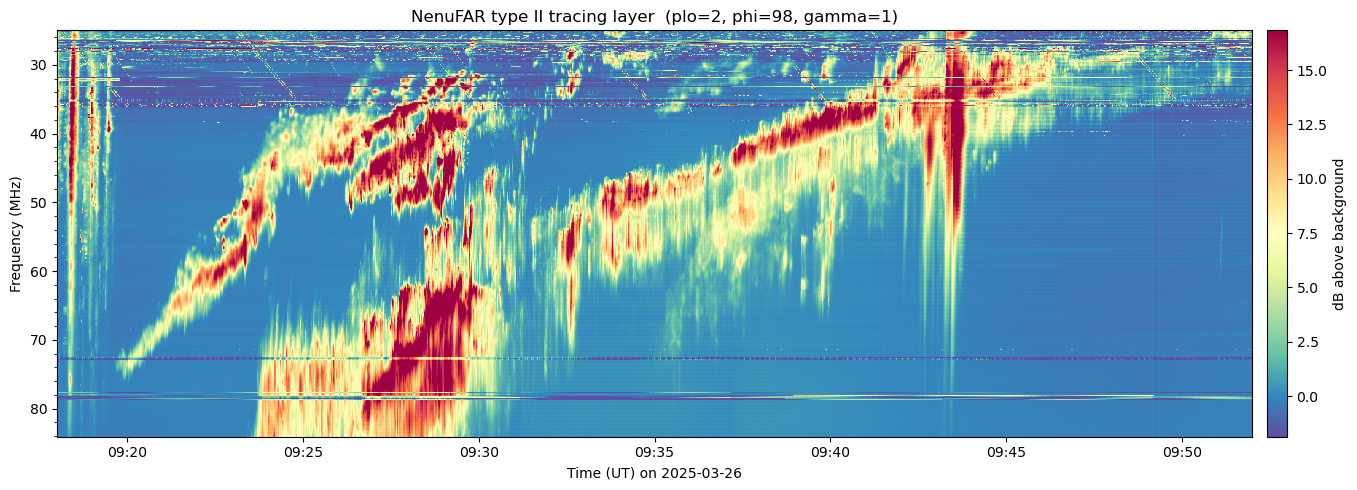

In [9]:
pl.plot_window(run)

## A.2 &middot; Coronal density models

*Method: `METHODS.md` &sect;4*

5 models x 4 folds = 20 combinations
saved /home/mnedal/data/png/type2_nenufar/density_models.png


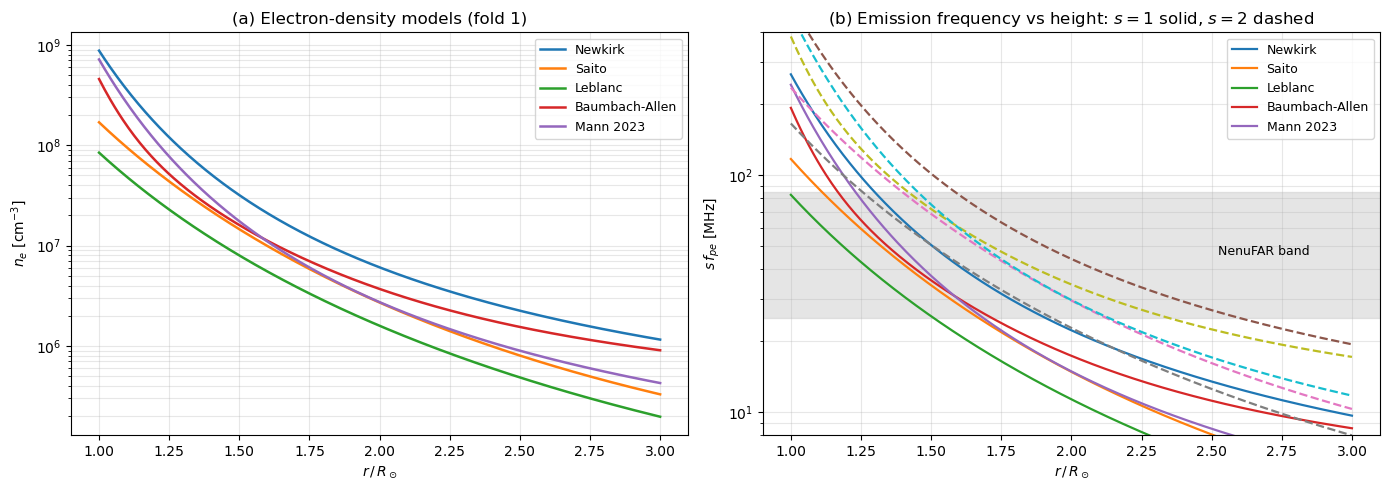

In [10]:
pl.build_model_grid(run)
pl.plot_density_models(run)

## A.3 &middot; Trace the lanes

*Method: `METHODS.md` &sect;5*

In [32]:
# If I changed anything in the loaded scripts, run this cell.
# Otherwise, skip it.
import functools
from typeii import spectra, tracing

tracing.RUN = run
tracing.draw_layer = functools.partial(spectra.draw_layer, run)

In [37]:
%matplotlib widget
tracer = t2.LaneTracer()          # LaneTracer(reset=True) discards everything and restarts

In [35]:
# Wipe everything?
# tracer = t2.LaneTracer(reset=True)

# Drop just one lane & keep the rest?
# from typeii import tracing
# for k in ('H lane 2',):
#     tracing.TRACE_STORE.pop(k, None)
#     tracing.TRACE_KIND.pop(k, None)
# tracing.TRACE_HISTORY[:] = [l for l in tracing.TRACE_HISTORY if l != 'H lane 2']

## A.3 &middot; Collect the traces

*Method: `METHODS.md` &sect;5*

In [38]:
%matplotlib inline
run.tracer = tracer
pl.collect_traces(run)

3 pass(es) over 4 lane(s): 2 x Fundamental, 2 x Harmonic

  NOTE: F lane 1, F lane 2, H lane 1, H lane 2 used Bezier AUTO-REPEATS. Those repeats are the same curve with its
        control points jittered by BEZIER_JITTER = 6.1 channels, so their spread measures that jitter,
        NOT how reproducibly you can place a curve on the lane. The error bars for those lanes are
        therefore fit-error-dominated and optimistic. For a genuine reproducibility error, untick
        "auto-repeats" and place the curve independently 3 times.
        Because of this the aggregation in A.4 will NOT divide the spread by sqrt(N_pass).


## A.3 &middot; Tracing quality

*Method: `METHODS.md` &sect;5*

saved /home/mnedal/data/png/type2_nenufar/traced_lanes_preview.png


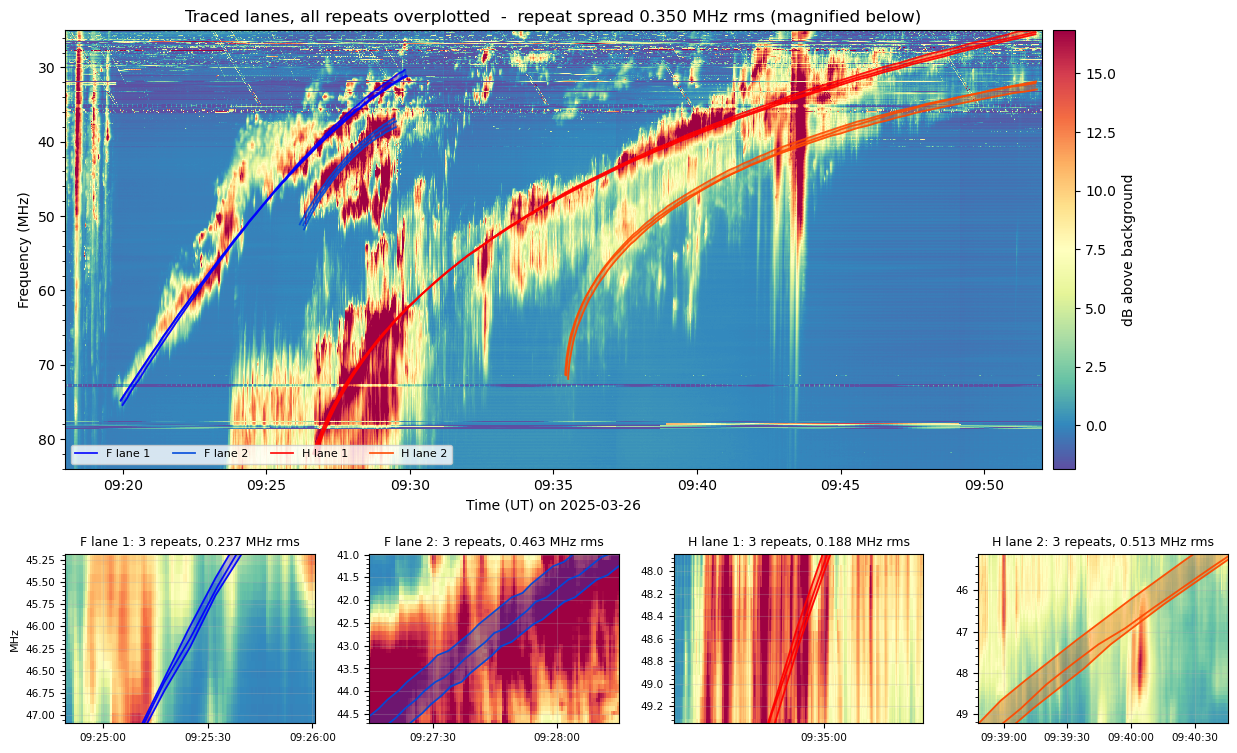

offset of each traced point from the local intensity maximum (search window +/-10 channels, channel width 98 kHz).
more than a channel or two of median offset means the trace is sitting off the lane.
median_on_trace / min_on_trace are the layer value ON the trace, in dB above background.
sigma_f_MHz is the per-point frequency uncertainty the lane fits will use.

  *** WARNING: H lane 2 sits at only 3.0 dB above background along its length (threshold 3). Part of it is very likely drawn across empty spectrum - check it against the traced-lanes figure before using it. A low offset-from-ridge does NOT vouch for a trace over empty sky.

sigma_f depends on the search window. rms offset [channels] vs half-width, against the uniform-in-window null (half/sqrt3):
   half    null    F lane 1    F lane 2    H lane 1    H lane 2   on/off-lane
      3    1.73        2.58        2.46        2.45        2.42     1.00
      5    2.89        4.27        3.90        3.97        3.96     0.99
     10    5

In [40]:
pl.plot_traced_lanes(run)

## A.4 &middot; Band split and the model-independent scalars

*Method: `METHODS.md` &sect;6*

In [42]:
pl.analyse_lanes(run)

Fundamental (s=1), compared over their 194 s of overlap:
    F lane 1       36.8 MHz  ->  upstream (lower)
    F lane 2       42.8 MHz  ->  downstream (upper)
Harmonic (s=2), compared over their 981 s of overlap:
    H lane 1       34.6 MHz  ->  upstream (lower)
    H lane 2       42.5 MHz  ->  downstream (upper)

analysing 4 lane(s) separately. Set MAKE_JOINT = True to add the combined F+H track as well.

lane fit quality (does a degree-3 polynomial in log10 f follow the traced curve?)
  F lane 1     rms residual  0.063 MHz =   0.1 x sigma_f   ok
  F lane 2     rms residual  0.033 MHz =   0.0 x sigma_f   ok
  H lane 1     rms residual  0.505 MHz =   0.7 x sigma_f   ok
  H lane 2     rms residual  1.063 MHz =   1.5 x sigma_f   ok

Reference density model: Newkirk x2

model-independent scalars, measured separately from each band
  Fundamental (s=1):  drift = -0.0741 +/- 0.0011 MHz/s,  rel. drift = -0.00149 +/- 0.00009 1/s,  X = 1.368 +/- 0.051,  M_A = 1.287 +/- 0.042,  BDW = 0.169 +/- 0

## A.5 &middot; Circular polarisation along each lane

*Method: `METHODS.md` &sect;7*

In [43]:
pl.polarisation(run)

signed mean V/I:  fundamental +0.0081,  harmonic -0.0038   (point-to-point scatter along a lane 0.0108)
  the two bands differ by 0.0119, which is 1.1x that scatter
  that is NOT a significant contrast. Fundamental plasma emission escapes in the o-mode and is expected to be the
  more strongly polarised of the two, but these numbers neither confirm nor contradict that expectation, and
  the band identification below does not rest on them.
mean |V/I| is also tabulated but do NOT use it to compare the bands: for |V/I| ~ the noise it just returns the noise level (0.0086 here).
V/I here is the mean of an ALREADY-DIVIDED ratio with no instrumental-leakage floor removed. Where Stokes I is near
the background that ratio is noise-dominated and averaging it pulls the result toward the noise mean, diluting the
band-to-band contrast. At the ~1% level measured here, treat these as an upper bound on a polarisation contrast,
not as a detection.


## A.5 &middot; Fundamental / harmonic consistency

*Method: `METHODS.md` &sect;7*

In [44]:
pl.fh_tests(run)

F lane 1 vs H lane 1, 09:26:40-09:29:51 UT  (191 s)

1. frequency ratio   f_H / f_F = 1.997 +/- 0.003 (s.e.m.)        (2.000 expected)
   the ratio RAMPS from 1.958 to 2.041 across the overlap instead of scattering about a constant,
   so its spread is not an uncertainty. That ramp is exactly test 2: d ln(f_H/f_F)/dt = rel drift H - rel drift F.
   Tests 1 and 2 are one statement seen twice - do not count them as two independent checks.
   measured on the traced points instead of the fitted cubics, the same ramp is 1.987 to 2.006
2. relative drift    over the overlap, measured on the TRACED POINTS in that window (29 F, 21 H samples per pass)
                     F: -0.001483 +/- 0.000067 1/s,   H: -0.001435 +/- 0.000038 1/s
                     differ by 3.2% = 0.6 sigma; f^-1 df/dt is free of the harmonic number, so these must agree
                     the fitted cubics give -0.001468 and -0.001251 (14.8% apart) - NOT the number to quote.
                     The overlap is the last 

## A.5 &middot; Consistency audit

*Method: `METHODS.md` &sect;7*

In [45]:
pl.audit_consistency(run)

  *** FLAG: shock speed: H lane 1 vs H lane 2 differ by 3.5 sigma (616 vs 512). the two split branches of one band bracket the same shock front (both averaged over the same window).
            Accounted for: the H branches are separating at +103 km/s (the split widening), which matches this difference to 0.0 sigma.
            Report it as the band split widening through the event, not as H lane 1 and H lane 2 disagreeing about one shock.
  *** FLAG: acceleration: H lane 1 vs H lane 2 differ by 14.9 sigma (121 vs -628). the two split branches of one band bracket the same shock front (both averaged over the same window).
            Accounted for: the H branches are separating at +103 km/s (the split widening), which matches this difference to 0.0 sigma.
            Report it as the band split widening through the event, not as H lane 1 and H lane 2 disagreeing about one shock.

acceleration: significance (|a| > 2 sigma), method bias floor, plausibility
the bias floor is what this chai

## A.5 &middot; The checks as a figure

*Method: `METHODS.md` &sect;7*

saved /home/mnedal/data/png/type2_nenufar/fundamental_harmonic_checks.png


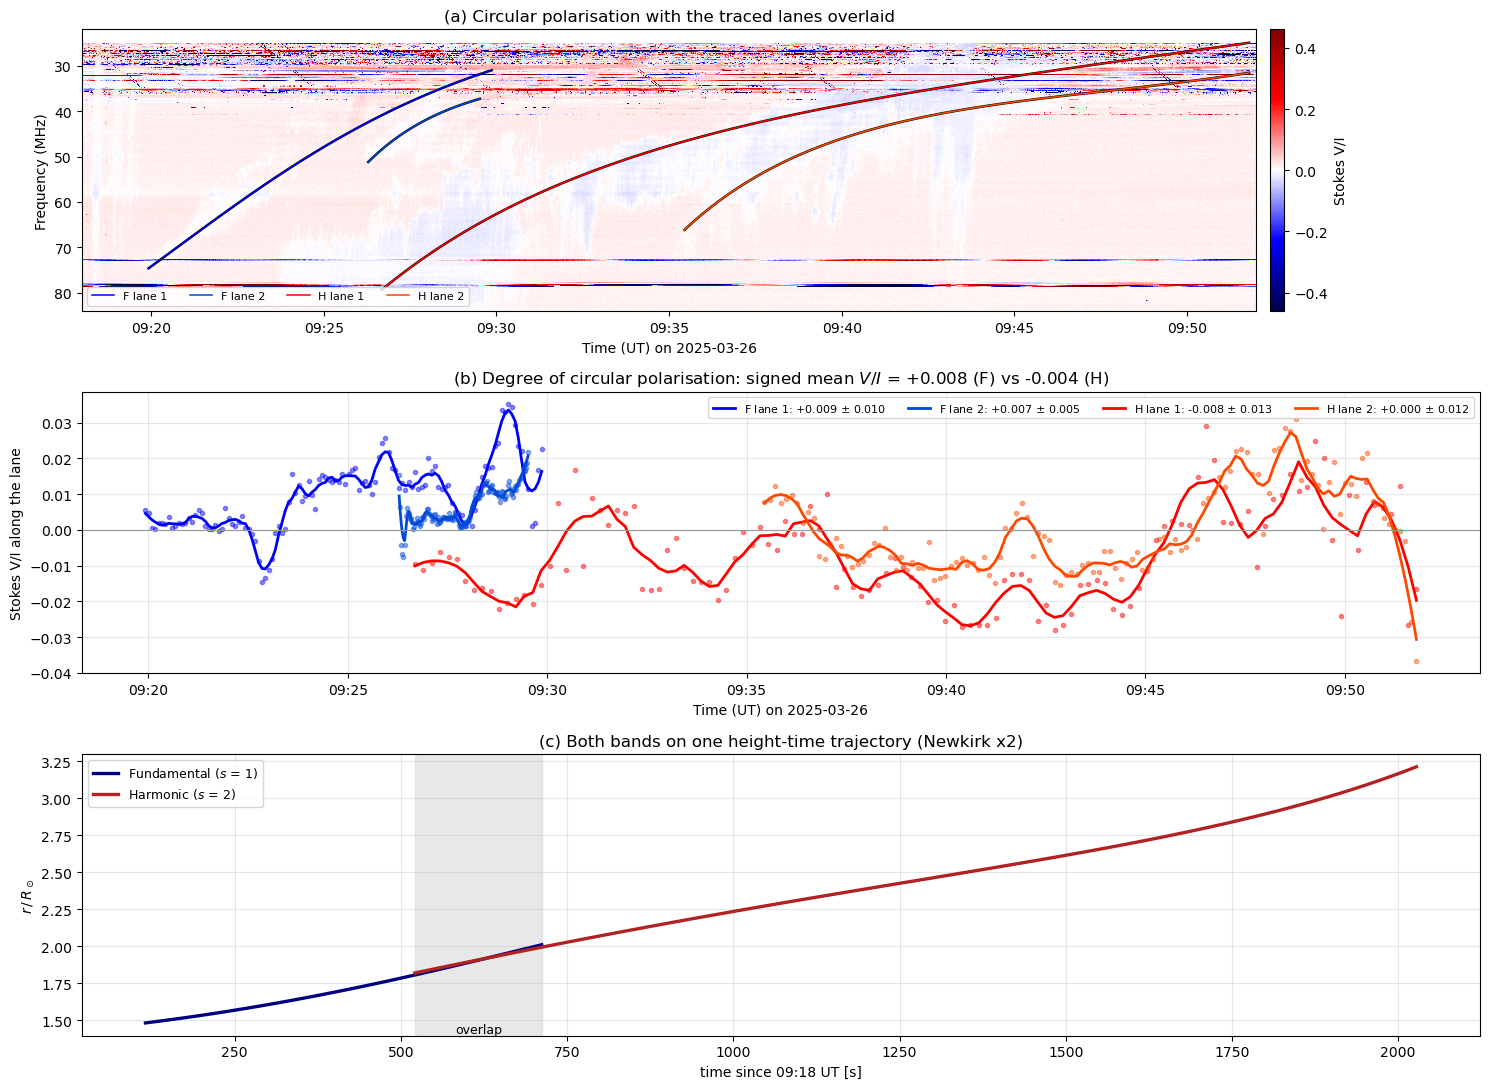

In [46]:
pl.plot_fh_checks(run)

## A.6 &middot; Kinematics and magnetic field

*Method: `METHODS.md` &sect;8*

saved /home/mnedal/data/png/type2_nenufar/typeii_kinematics_Bfield.png


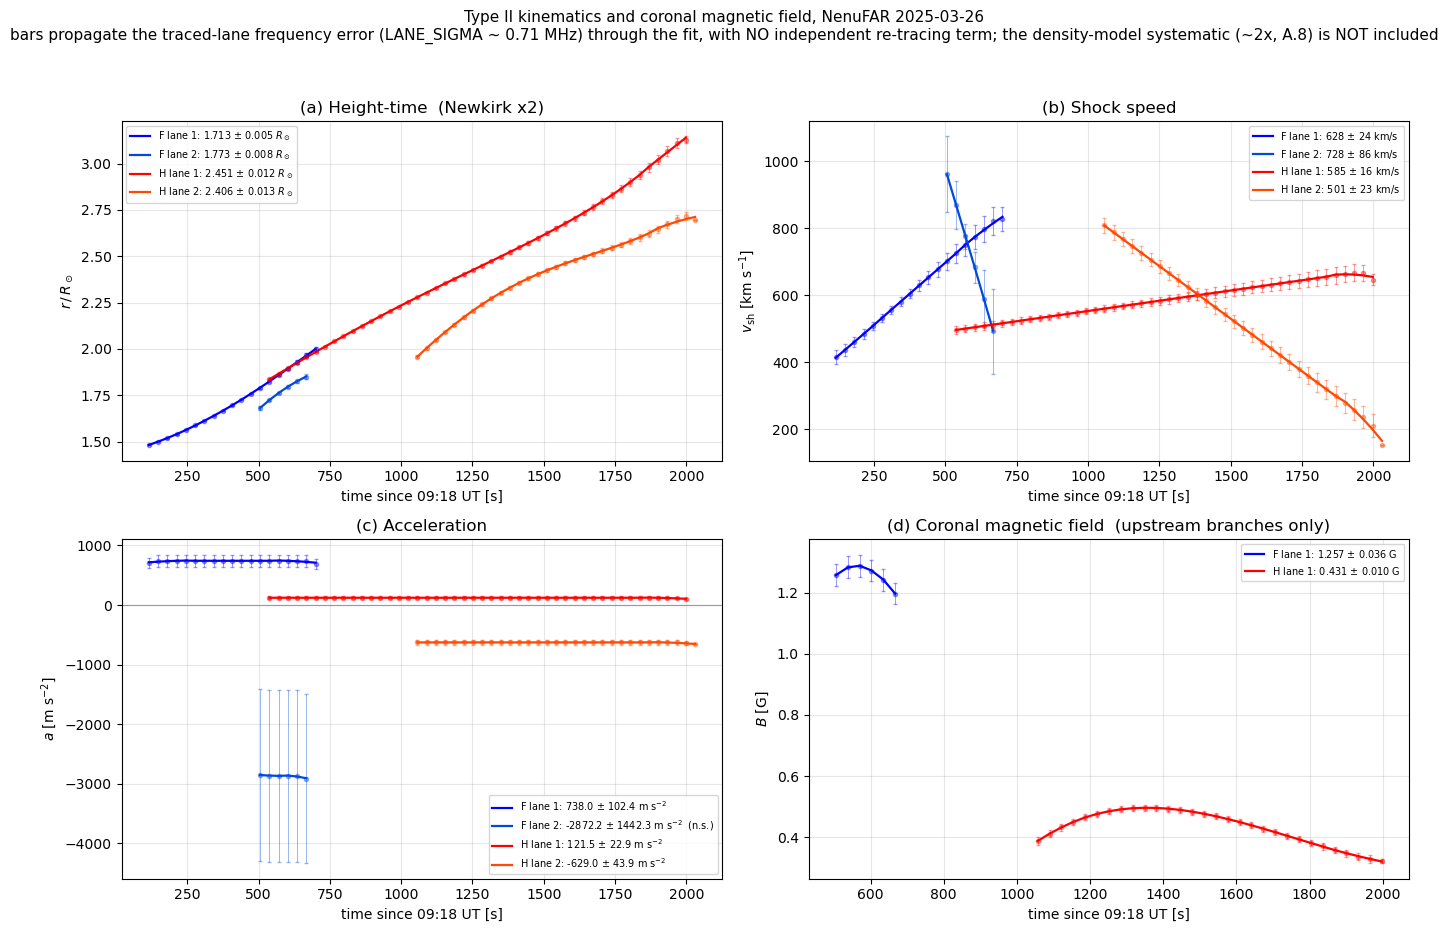

In [47]:
pl.plot_kinematics(run)

## A.7 &middot; Height-time fitting methods

*Method: `METHODS.md` &sect;9*

height-time fits and the model sweep use: F lane 1  (Newkirk x2)


Polynomial:   0%|          | 0/300 [00:00<?, ?it/s]

Polynomial         chi2_red =    0.240 (not a goodness of fit - see note), rms residual = 0.0035 Rsun


Gallagher (2003):   0%|          | 0/300 [00:00<?, ?it/s]

Gallagher (2003)   chi2_red =    0.041 (not a goodness of fit - see note), rms residual = 0.0015 Rsun


Byrne (2013):   0%|          | 0/300 [00:00<?, ?it/s]

Byrne (2013)       chi2_red =    0.067 (not a goodness of fit - see note), rms residual = 0.0012 Rsun
3 of 3 methods converged

spread between methods: mean speed 2.4% (615-630 km/s), mean acceleration 17.1% (701-821 m/s^2)
against A.6 for the same lane: v_sh 628 +/- 24 km/s, a +738 +/- 102 m/s^2
  The speeds agree; the accelerations need not, and the difference is not an error in
  either. A.6 fits the lane over KIN_N_DENSE samples of its OWN traced span and averages
  the result over the Monte-Carlo draws; this section fits the shared-grid points that
  fall inside the lane and bootstraps them. r(t) is not exactly a quadratic, so a fitted
  curvature depends on where the samples sit, so the spread between
  between the three methods is the uncertainty on a, not any single method's error
  bar. Quote A.6 for per-lane numbers; quote this section for method sensitivity.
saved /home/mnedal/data/png/type2_nenufar/typeii_kinematics_fit_comparison.png


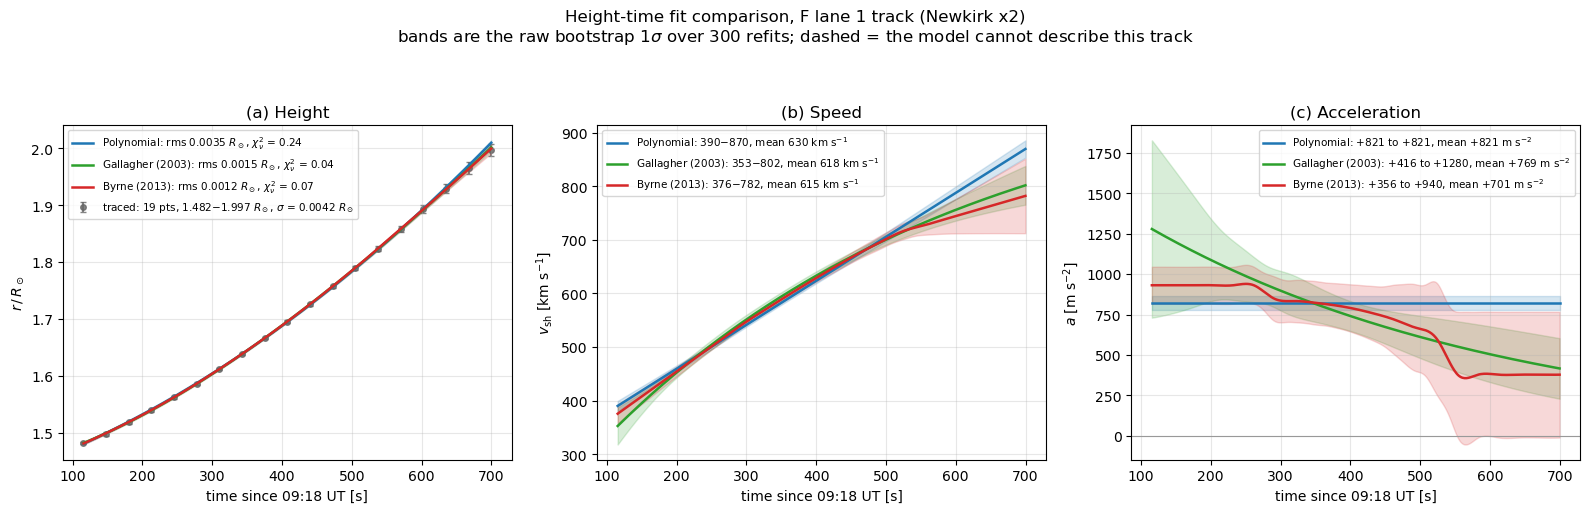

In [48]:
pl.height_time_fits(run)
pl.plot_fit_comparison(run)

## A.7 &middot; Fit comparison table

*Method: `METHODS.md` &sect;9*

In [49]:
pl.fit_comparison_table(run)

## A.8 &middot; The density-model systematic

*Method: `METHODS.md` &sect;10*

In [50]:
pl.model_sweep(run)

model x fold:   0%|          | 0/20 [00:00<?, ?it/s]

the full chain was recomputed on the F lane 1 track for all 20 density profiles (5 models x 4 folds); only n_e(r) changed, the tracing did not
the spread down each column IS the systematic error; compare it with the statistical errors in A.6 before quoting anything


## A.8 &middot; Characteristics across the grid

*Method: `METHODS.md` &sect;10*

saved /home/mnedal/data/png/type2_nenufar/characteristics_vs_model_fold.png


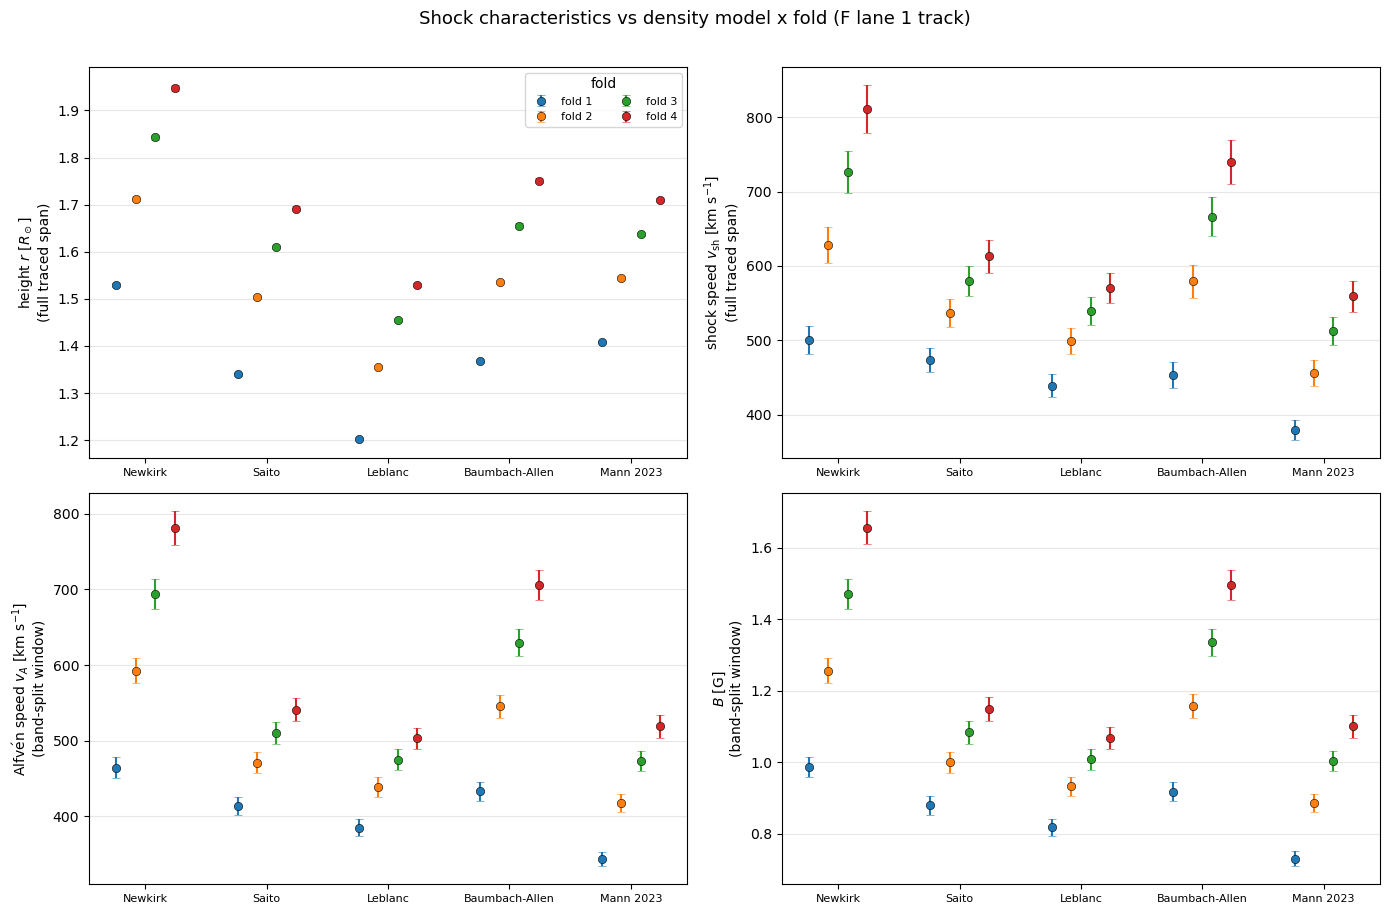

In [51]:
pl.plot_model_sweep(run)

## A.9 &middot; Magnetic field against published profiles

*Method: `METHODS.md` &sect;11*

saved /home/mnedal/data/png/type2_nenufar/Bfield_comparison.png


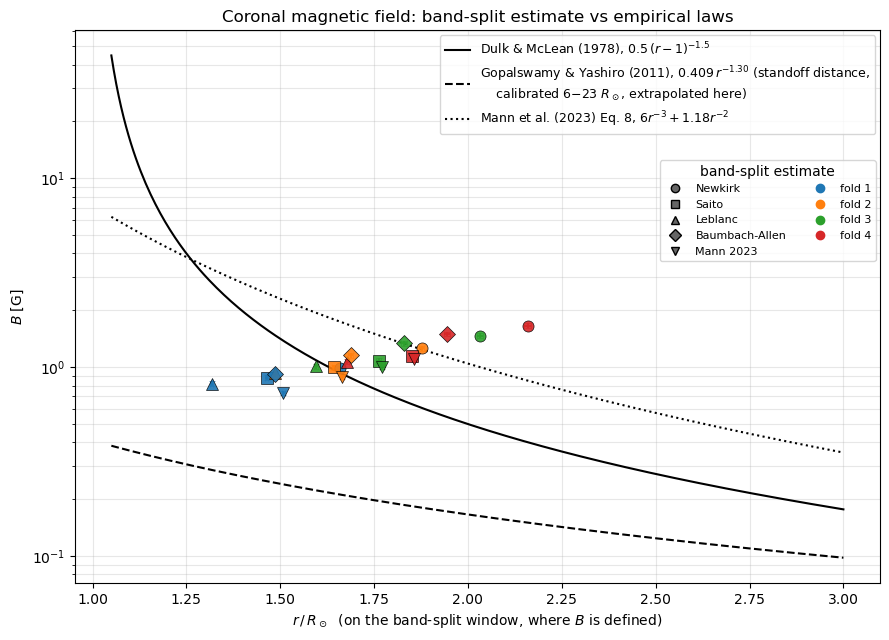

In [52]:
pl.plot_bfield(run)

## A.10 &middot; Characteristics table

*Method: `METHODS.md` &sect;12*

In [53]:
pl.characteristics_table(run)

written to /home/mnedal/data/png/type2_nenufar

  *** WARNING: 2 file(s) in /home/mnedal/data/png/type2_nenufar were NOT written by this run and are left over from an earlier one:
        bezier_cubic
        bezier_quadratic
      delete them, or move this run to a fresh OUTDIR, before using anything from that folder.


## A.10 &middot; Results text

*Method: `METHODS.md` &sect;12*

In [54]:
pl.results_text(run)

Type II radio burst, 2025-03-26, NenuFAR

observed 09:19-09:51 UT; one shock seen in both harmonics
every lane is analysed separately

Fundamental band (s = 1)
------------------------------------------------------------------------------
  drift rate                   -0.0741 +/- 0.0011 MHz/s
  relative drift (1/f)(df/dt)  -0.00149 +/- 0.00009 1/s
  relative band split          0.169 +/- 0.015
  density jump X               1.368 +/- 0.051   (model-independent)
  Alfven Mach number M_A       1.287 +/- 0.042   (model-independent)

  F lane 1  [upstream (lower)]
    traced                     09:19:55-09:29:51 UT over 31.1-74.9 MHz
    -- over the full traced span (19 grid points) --
    height r                   1.7128 +/- 0.0052 Rsun
    shock speed v_sh           628 +/- 24 km/s
    acceleration a             738.0 +/- 102.4 m/s^2
    signed mean V/I            +0.0095 +/- 0.0095 (sd)
    -- on the band-split window 09:26:25-09:29:07 UT (6 of 19 grid points) --
    height r         

## A.11 &middot; Height-time tracks for every density model

*Method: `METHODS.md` &sect;13*

In [55]:
pl.export_tracks(run)

exporting model x fold:   0%|          | 0/20 [00:00<?, ?it/s]

6120 rows over 20 model x fold combinations x 4 lanes, at 10 s cadence
  height_time_all_models.csv      r(t) per lane per model, BOTH height conventions
  height_time_model_summary.csv   one row per model x fold x lane
  model_independent_scalars.csv   X and M_A, no density model involved

across the grid the UPSTREAM lanes (F lane 1, H lane 1) span 0.04 to 2.93 Rsun above the limb, mean speed 281-903 km/s
  all four lanes together span 0.04 to 2.93 Rsun and 255-916 km/s
  these are means over each lane's FULL traced span, which is the right window for a height-time comparison


## A.11 &middot; The exported tracks

*Method: `METHODS.md` &sect;13*

saved /home/mnedal/data/png/type2_nenufar/height_time_all_models.png


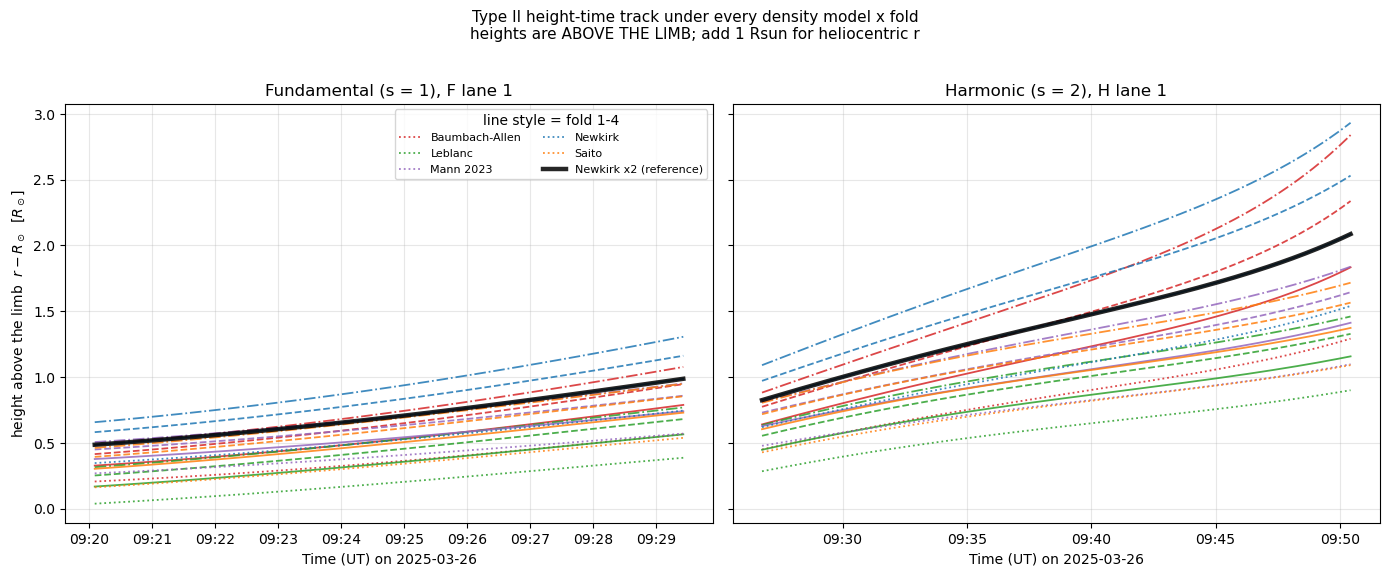

In [56]:
pl.plot_export_tracks(run)